# Once dólares, un teléfono de teclas y cinco países

Once dólares por niño. Una llamada de veinte minutos, una vez por semana, durante ocho semanas. Sin internet, sin tableta, sin aula.

Con eso, un equipo midió cuánto se puede sostener el aprendizaje cuando la escuela se cierra — y lo midió al mismo tiempo en India, Kenia, Nepal, Filipinas y Uganda.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Mobile education builds resilience during shocks in five countries* — Angrist et al., *Nature* (9 de septiembre de 2026)

**DOI:** [10.1038/s41586-026-10990-x](https://doi.org/10.1038/s41586-026-10990-x)

**Video:** [Pendiente]

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-09-tutorias-telefono-cinco-paises/notebook.ipynb)

## Qué midieron

Cuando una epidemia o una inundación cierra las escuelas, la respuesta habitual es mudar la clase a internet. En los países donde esto pasa más, menos del 15% de los hogares tiene conexión — pero más del 70% tiene un celular, aunque sea de teclas.

Así que el equipo probó dos formas de enseñar por teléfono: mensajes de texto con ejercicios, y esos mismos mensajes **más** una tutoría por llamada. Cinco ensayos aleatorizados —a cada niño le tocó por sorteo si entraba al grupo con tutoría o al de comparación—, uno por país, con 16.936 niños inscritos y 9.148 en el análisis final.

La medida de aprendizaje son **operaciones ganadas**: una escala de 0 a 4 según hasta dónde llega el niño (0 = no suma todavía, 1 = suma, 2 = resta, 3 = multiplica, 4 = divide). Ganar "una operación" es subir un peldaño completo de esa escalera.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
NIVEL_CONFIANZA = 0.90            # Los intervalos que dibujamos (el paper usa 90%)
COSTO_POR_NINO_USD = 11           # Costo de la tutoría por llamada, por niño
COMPARADOR_PRESENCIAL_USD = 2500  # Tutoría presencial intensiva, por niño

COLOR_LLAMADA = '#2563EB'      # Llamada + SMS
COLOR_SMS = '#D97706'          # Solo SMS
COLOR_ALERTA = '#DC2626'       # Contraste / referencia
COLOR_GOBIERNO = '#059669'     # Entrega por gobierno
COLOR_CONTEXTO = '#BBBBBB'

FUENTE = ('Fuente: Angrist et al. (2026), Nature | '
          'Datos: tablas y Extended Data del propio paper')

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats


def num(v, d=3):
    """Formato español: coma para decimales, punto para miles."""
    return f'{v:,.{d}f}'.replace(',', '@').replace('.', ',').replace('@', '.')


def pval(p):
    """El p-valor como se escribe en español, con el piso convencional."""
    return 'p < 0,001' if p < 0.001 else f'p = {num(p)}'


def _tick_es(v, _):
    """Los ejes también llevan coma decimal, no punto."""
    t = f'{v:.2f}'.rstrip('0').rstrip('.')
    return (t if t else '0').replace('.', ',')


TICKS_ES = FuncFormatter(_tick_es)


RAW = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
BASE = f'{RAW}/papers/2026-09-09-tutorias-telefono-cinco-paises'

# Estilo CaM: local primero, luego el del repo
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{RAW}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Descarga automática (para quien abra esto en Colab)
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
ARCHIVOS = ['efectos_por_pais.csv', 'efectos_agrupados_sd.csv', 'gobierno_vs_ong.csv',
            'descripcion_ensayos.csv', 'costo_efectividad.csv', 'creencias_docentes.csv']
for archivo in ARCHIVOS:
    destino = f'datos/{archivo}'
    if not os.path.exists(destino):
        urllib.request.urlretrieve(f'{BASE}/datos/{archivo}', destino)

efectos = pd.read_csv('datos/efectos_por_pais.csv')
agrupados = pd.read_csv('datos/efectos_agrupados_sd.csv')
gob_ong = pd.read_csv('datos/gobierno_vs_ong.csv')
ensayos = pd.read_csv('datos/descripcion_ensayos.csv')
costos = pd.read_csv('datos/costo_efectividad.csv')
docentes = pd.read_csv('datos/creencias_docentes.csv')

print('Efectos por país :', efectos.shape, '|', list(efectos.columns[:6]))
print('Agrupados (d.e.) :', agrupados.shape, '|', list(agrupados.columns[:5]))
print('Gobierno vs ONG  :', gob_ong.shape)
print('Los cinco ensayos:', ensayos.shape)
print()
print('Unidades — OJO: dos escalas distintas, nunca en el mismo eje')
print('  · efectos_por_pais.csv   → operaciones ganadas (escala 0-4)')
print('  · efectos_agrupados_sd.csv → desviaciones estándar del grupo control')
print()
n_total = int(efectos.drop_duplicates('pais')['n_observaciones'].sum())
print(f'N analítico agrupado: {n_total:,}'.replace(',', '.'))
print(ensayos[['pais', 'tamano_muestra', 'muestra_endline', 'grados',
               'entrega_gobierno']].to_string(index=False))

Efectos por país : (9, 14) | ['pais', 'tratamiento', 'efecto_ops_sin_controles', 'se_sin_controles', 'p_sin_controles', 'efecto_ops_con_controles']
Agrupados (d.e.) : (8, 8) | ['tratamiento', 'especificacion', 'efecto_sd', 'se', 'p_valor']
Gobierno vs ONG  : (9, 8)
Los cinco ensayos: (5, 12)

Unidades — OJO: dos escalas distintas, nunca en el mismo eje
  · efectos_por_pais.csv   → operaciones ganadas (escala 0-4)
  · efectos_agrupados_sd.csv → desviaciones estándar del grupo control

N analítico agrupado: 9.148
     pais  tamano_muestra  muestra_endline grados entrega_gobierno
    India             850              765    3–5               No
    Kenia            6724             3556    1–2               No
    Nepal            3732             3351    3–5               Sí
Filipinas            3492             3164    3–4               Sí
   Uganda            2138             1495    3–5               No


## Aquí está.

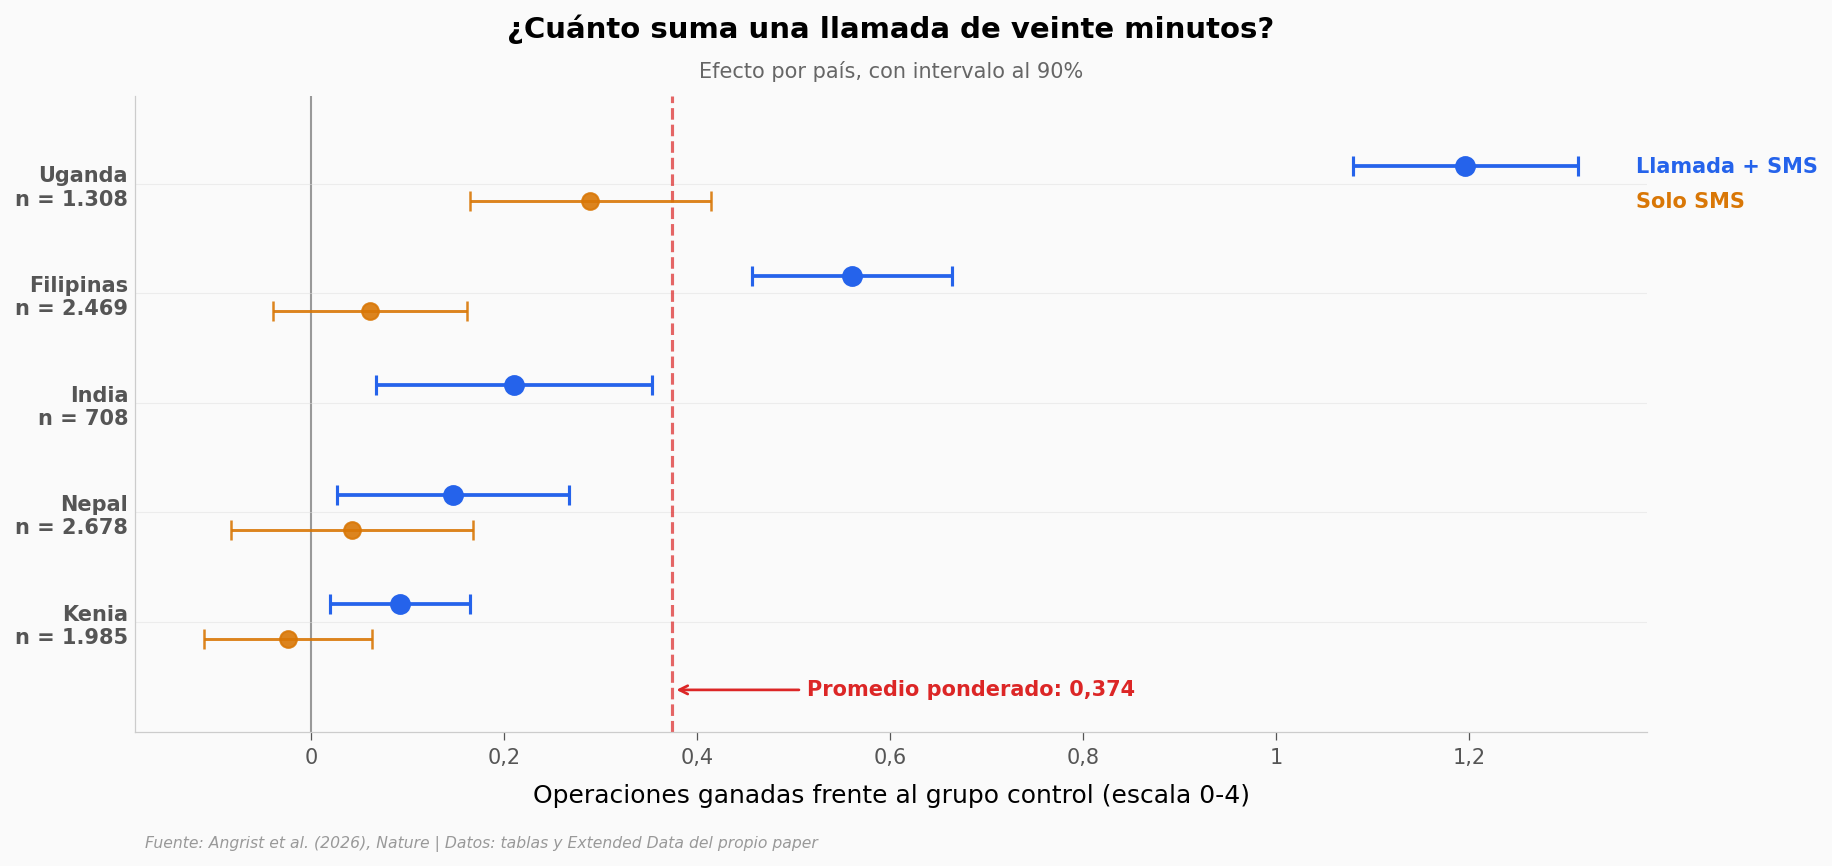

Efecto de la llamada, país por país (operaciones ganadas; e.e. = error estándar):
  Uganda      1,196 (e.e. 0,071, p < 0,001) → +66,3% sobre su control
  Filipinas   0,560 (e.e. 0,063, p < 0,001) → +40,3% sobre su control
  India       0,210 (e.e. 0,087, p = 0,016) → +7,7% sobre su control
  Nepal       0,147 (e.e. 0,073, p = 0,045) → +8,7% sobre su control
  Kenia       0,092 (e.e. 0,044, p = 0,039) → +6,5% sobre su control

Mediana entre países : 0,210 | RIC: 0,147 a 0,560
Extremos             : 0,092 a 1,196 = 13 veces de diferencia
Promedio ponderado   : 0,374 (e.e. 0,028)
Heterogeneidad       : I² = 98,0%  (Q = 197,1, gl = 4, p = 1.6e-41)
Promedio si cada país tiene su propio efecto (efectos aleatorios):
                       0,441 (e.e. 0,203, τ² = 0,201)


In [2]:
llamada = efectos[efectos['tratamiento'] == 'Llamada + SMS'].copy()
solo_sms = efectos[efectos['tratamiento'] == 'Solo SMS'].copy()

# Intervalo al 90%, que es el que reporta el paper
z = stats.norm.ppf(0.5 + NIVEL_CONFIANZA / 2)
for tabla in (llamada, solo_sms):
    tabla['ic_bajo'] = tabla['efecto_ops_con_controles'] - z * tabla['se_con_controles']
    tabla['ic_alto'] = tabla['efecto_ops_con_controles'] + z * tabla['se_con_controles']
    tabla['ganancia_pct'] = (100 * tabla['efecto_ops_con_controles']
                             / tabla['media_control_ops'])

llamada = llamada.sort_values('efecto_ops_con_controles').reset_index(drop=True)

# Modelo de efectos ALEATORIOS (DerSimonian-Laird): con I² del 98% no se
# sostiene que exista un efecto común, así que reportamos también el promedio
# que admite un efecto propio por país — y su incertidumbre real.
def _dl(tabla, Q, gl, peso):
    tau2 = max(0.0, (Q - gl) / (peso.sum() - (peso ** 2).sum() / peso.sum()))
    w = 1 / (tabla['se_con_controles'] ** 2 + tau2)
    return tau2, np.average(tabla['efecto_ops_con_controles'], weights=w), np.sqrt(1 / w.sum())


# Meta-análisis de varianza inversa sobre las cinco estimaciones (en operaciones).
# El paper NO reporta este agregado: su cifra agrupada está en desviaciones
# estándar. Lo calculamos para poder medir la heterogeneidad entre países.
peso = 1 / llamada['se_con_controles'] ** 2
meta = np.average(llamada['efecto_ops_con_controles'], weights=peso)
meta_se = np.sqrt(1 / peso.sum())
Q = float((peso * (llamada['efecto_ops_con_controles'] - meta) ** 2).sum())
gl = len(llamada) - 1
I2 = max(0.0, 100 * (Q - gl) / Q)
p_Q = stats.chi2.sf(Q, gl)
tau2, meta_dl, se_dl = _dl(llamada, Q, gl, peso)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axvline(0, color='#999999', linewidth=1, zorder=1)

for i, fila in llamada.iterrows():
    ax.errorbar(fila['efecto_ops_con_controles'], i + 0.16,
                xerr=[[fila['efecto_ops_con_controles'] - fila['ic_bajo']],
                      [fila['ic_alto'] - fila['efecto_ops_con_controles']]],
                fmt='o', color=COLOR_LLAMADA, markersize=9, capsize=5,
                capthick=1.5, elinewidth=1.8, zorder=5)
    par = solo_sms[solo_sms['pais'] == fila['pais']]
    if not par.empty:
        s = par.iloc[0]
        ax.errorbar(s['efecto_ops_con_controles'], i - 0.16,
                    xerr=[[s['efecto_ops_con_controles'] - s['ic_bajo']],
                          [s['ic_alto'] - s['efecto_ops_con_controles']]],
                    fmt='o', color=COLOR_SMS, markersize=8, capsize=5,
                    capthick=1.2, elinewidth=1.4, alpha=0.9, zorder=4)

ax.axvline(meta, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.7, zorder=2)
ax.annotate(f'Promedio ponderado: {num(meta)}',
            xy=(meta, -0.62), xytext=(meta + 0.14, -0.62),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA, va='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))

etiquetas = [f"{p}\nn = {int(n):,}".replace(',', '.')
             for p, n in zip(llamada['pais'], llamada['n_observaciones'])]
ax.set_yticks(range(len(llamada)))
ax.set_yticklabels(etiquetas, fontsize=10, fontweight='bold')
ax.set_ylim(-1.0, len(llamada) - 0.2)
ax.set_xlabel('Operaciones ganadas frente al grupo control (escala 0-4)')
ax.set_title('¿Cuánto suma una llamada de veinte minutos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Efecto por país, con intervalo al 90%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Etiquetas al margen derecho, cada una a la altura de su propia serie:
# pegadas al punto chocarían con la línea del promedio ponderado.
tope = len(llamada) - 1
x_etiqueta = llamada['ic_alto'].iloc[tope] + 0.06
ax.text(x_etiqueta, tope + 0.16, 'Llamada + SMS',
        fontsize=10, color=COLOR_LLAMADA, fontweight='bold', va='center')
ax.text(x_etiqueta, tope - 0.16, 'Solo SMS',
        fontsize=10, color=COLOR_SMS, fontweight='bold', va='center')
ax.xaxis.set_major_formatter(TICKS_ES)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_efectos_por_pais.png', dpi=200, bbox_inches='tight')
plt.show()

ef = llamada['efecto_ops_con_controles']
print('Efecto de la llamada, país por país (operaciones ganadas; e.e. = error estándar):')
for _, f in llamada.sort_values('efecto_ops_con_controles', ascending=False).iterrows():
    print(f"  {f['pais']:<10} {num(f['efecto_ops_con_controles']):>6} "
          f"(e.e. {num(f['se_con_controles'])}, {pval(f['p_con_controles'])}) "
          f"→ +{num(f['ganancia_pct'], 1)}% sobre su control")
print()
print(f'Mediana entre países : {num(ef.median())} '
      f'| RIC: {num(ef.quantile(0.25))} a {num(ef.quantile(0.75))}')
print(f'Extremos             : {num(ef.min())} a {num(ef.max())} '
      f'= {num(ef.max() / ef.min(), 0)} veces de diferencia')
print(f'Promedio ponderado   : {num(meta)} (e.e. {num(meta_se)})')
print(f'Heterogeneidad       : I² = {num(I2, 1)}%  (Q = {num(Q, 1)}, gl = {gl}, p = {p_Q:.1e})')
print(f'Promedio si cada país tiene su propio efecto (efectos aleatorios):')
print(f'                       {num(meta_dl)} (e.e. {num(se_dl)}, τ² = {num(tau2)})')

Dos cosas saltan a la vez.

La primera: **la llamada movió el aprendizaje en los cinco países**, y en ninguno el intervalo toca el cero. Eso es raro de conseguir con una intervención educativa repetida en cinco contextos distintos.

La segunda es más incómoda: **el tamaño de ese movimiento no se parece entre países**. Uganda ganó 1,196 operaciones y Kenia 0,092 — trece veces de diferencia. La mediana está en 0,210 operaciones, con un rango intercuartílico de 0,147 a 0,560: la distribución está muy dispersa, así que "el efecto típico" es un número de resumen que casi ningún país vive. La medida formal de esa dispersión, I², da 98,0%: prácticamente toda la variación entre estimaciones excede lo que explicaría el azar del muestreo. Eso tiene una consecuencia para el promedio ponderado de 0,374 que marca la línea roja: está calculado suponiendo que existe UN efecto común, y su error estándar (0,028) hereda ese supuesto. Si en cambio se admite que cada país tiene su propio efecto, el promedio sube a 0,441 pero su error estándar se multiplica por siete (0,203), y el intervalo al 90% va de 0,11 a 0,78. La línea roja marca dónde cae el centro, no cuánto sabemos de él.

Y hay una razón de diseño detrás de parte de esa brecha: **los cinco ensayos no son cinco copias del mismo experimento**. Kenia evaluó grados 1 y 2, donde el techo de la prueba era restar números de dos cifras; Uganda evaluó grados 3 a 5, con la división arriba. Con menos peldaños disponibles, hay menos peldaños que ganar.

El SMS solo, en naranja, cuenta otra historia: se queda pegado al cero en casi todas partes.

## Entonces, ¿el mensaje de texto sirve o no?

Para responder eso hay que salir de la escala de operaciones y pasar a la que permite juntar los cinco países: **desviaciones estándar del grupo control**. Es la vara común de la investigación educativa, y es la que el paper usa para su cifra principal.

Y aquí el método pesa: hay cuatro maneras razonables de juntar cinco ensayos —tratar a todos los niños como una sola muestra o darle el mismo peso a cada país, con o sin ajuste por grado escolar—. Veamos si la respuesta cambia según cuál se elija.

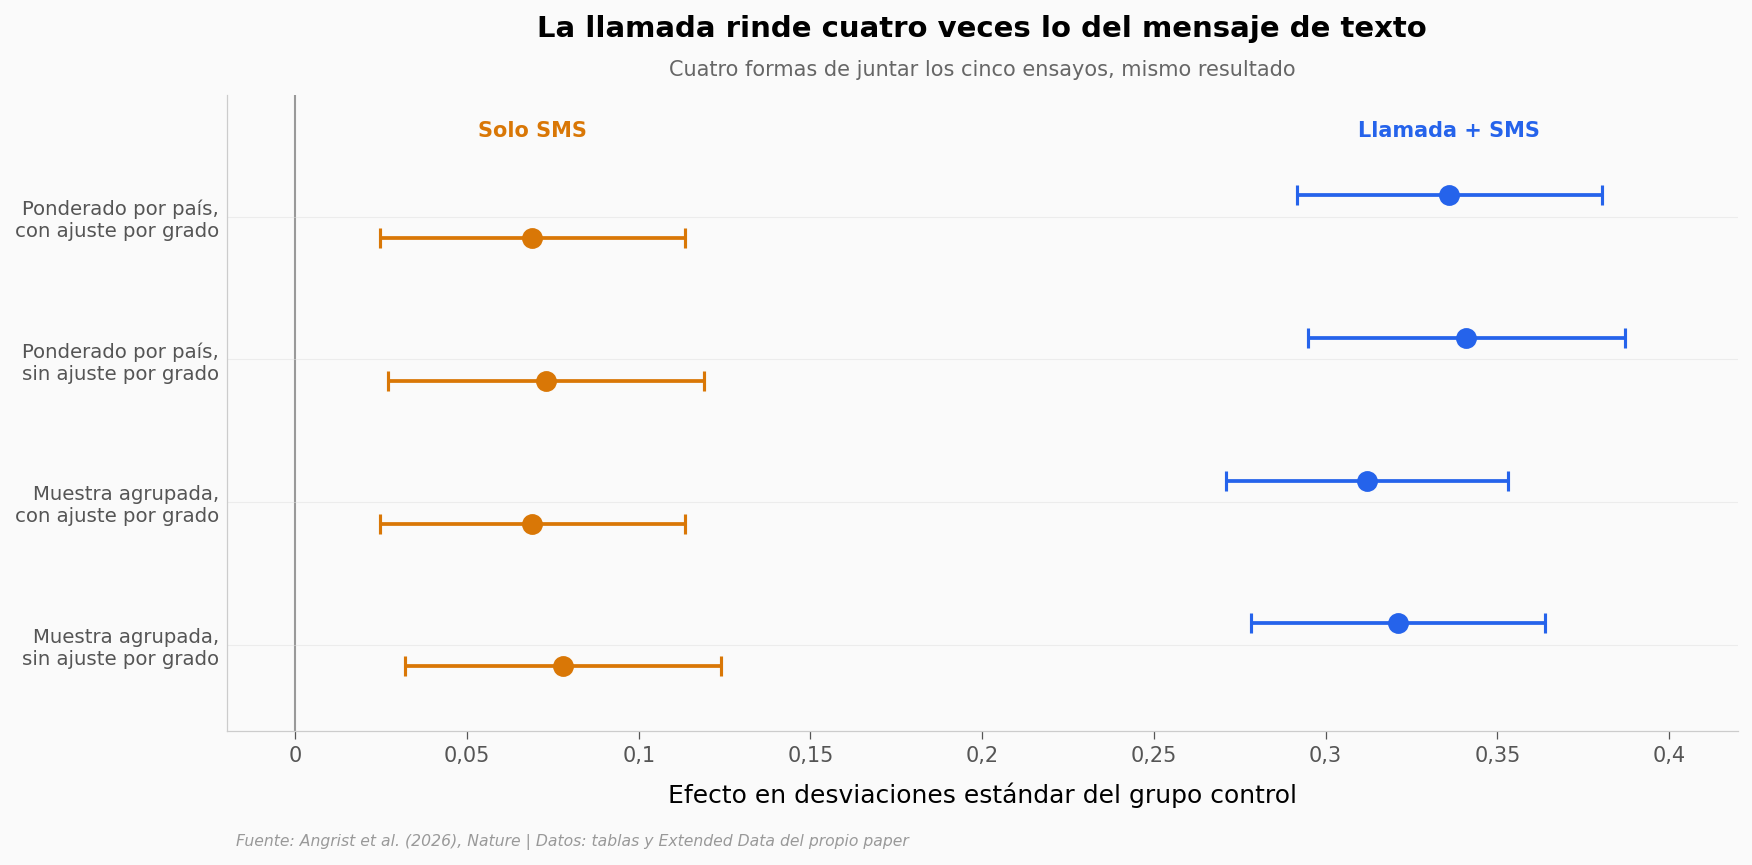

Llamada + SMS : 0,321 d.e. (e.e. 0,026, p < 0,001)
Solo SMS      : 0,078 d.e. (e.e. 0,028, p = 0,006)
Razón         : la llamada rinde 4,1 veces lo del SMS solo

Rango entre las cuatro especificaciones:
  Llamada + SMS  0,312 a 0,341 d.e.
  Solo SMS       0,069 a 0,078 d.e.

País por país, el SMS solo (operaciones ganadas):
  Kenia      -0,024 (p = 0,642) → distinguible de cero: no
  Nepal      +0,042 (p = 0,578) → distinguible de cero: no
  Filipinas  +0,061 (p = 0,318) → distinguible de cero: no
  Uganda     +0,289 (p < 0,001) → distinguible de cero: sí
  India      sin brazo de solo-SMS


In [3]:
def nombre_spec(fila):
    grado = 'con ajuste por grado' if fila['efectos_fijos_grado'] == 'Sí' else 'sin ajuste por grado'
    base = 'Muestra agrupada' if fila['especificacion'] == 'Muestra agrupada' else 'Ponderado por país'
    return f'{base},\n{grado}'

agrupados = agrupados.copy()
agrupados['spec'] = agrupados.apply(nombre_spec, axis=1)
orden = ['Muestra agrupada,\nsin ajuste por grado', 'Muestra agrupada,\ncon ajuste por grado',
         'Ponderado por país,\nsin ajuste por grado', 'Ponderado por país,\ncon ajuste por grado']

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axvline(0, color='#999999', linewidth=1, zorder=1)

for i, spec in enumerate(orden):
    for trat, color, desp in (('Llamada + SMS', COLOR_LLAMADA, 0.15),
                              ('Solo SMS', COLOR_SMS, -0.15)):
        fila = agrupados[(agrupados['spec'] == spec) & (agrupados['tratamiento'] == trat)].iloc[0]
        ax.errorbar(fila['efecto_sd'], i + desp, xerr=z * fila['se'],
                    fmt='o', color=color, markersize=9, capsize=5,
                    capthick=1.5, elinewidth=1.8, zorder=5)

ax.set_yticks(range(len(orden)))
ax.set_yticklabels(orden, fontsize=9.5)
ax.set_ylim(-0.6, len(orden) - 0.15)
ax.set_xlim(-0.02, 0.42)
ax.set_xlabel('Efecto en desviaciones estándar del grupo control')
ax.set_title('La llamada rinde cuatro veces lo del mensaje de texto',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cuatro formas de juntar los cinco ensayos, mismo resultado',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Etiquetas por encima del par superior, centradas sobre cada serie:
# al lado del punto se montarían sobre las barras de error.
arriba = agrupados[agrupados['spec'] == orden[-1]]
for trat, color in (('Llamada + SMS', COLOR_LLAMADA), ('Solo SMS', COLOR_SMS)):
    x = arriba[arriba['tratamiento'] == trat]['efecto_sd'].iloc[0]
    ax.text(x, len(orden) - 0.4, trat, fontsize=10, color=color,
            fontweight='bold', ha='center', va='center')
ax.xaxis.set_major_formatter(TICKS_ES)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/agrupado_sd.png', dpi=200, bbox_inches='tight')
plt.show()

principal = agrupados[(agrupados['especificacion'] == 'Muestra agrupada') &
                      (agrupados['efectos_fijos_grado'] == 'No')]
lla = principal[principal['tratamiento'] == 'Llamada + SMS'].iloc[0]
sms = principal[principal['tratamiento'] == 'Solo SMS'].iloc[0]
print(f"Llamada + SMS : {num(lla['efecto_sd'])} d.e. (e.e. {num(lla['se'])}, {pval(lla['p_valor'])})")
print(f"Solo SMS      : {num(sms['efecto_sd'])} d.e. (e.e. {num(sms['se'])}, {pval(sms['p_valor'])})")
print(f"Razón         : la llamada rinde {num(lla['efecto_sd'] / sms['efecto_sd'], 1)} veces lo del SMS solo")
print()
print('Rango entre las cuatro especificaciones:')
for trat in ('Llamada + SMS', 'Solo SMS'):
    sub = agrupados[agrupados['tratamiento'] == trat]
    print(f"  {trat:<14} {num(sub['efecto_sd'].min())} a {num(sub['efecto_sd'].max())} d.e.")
print()
print('País por país, el SMS solo (operaciones ganadas):')
for _, f in solo_sms.iterrows():
    marca = 'sí' if f['p_con_controles'] < 0.05 else 'no'
    signo = '+' if f['efecto_ops_con_controles'] >= 0 else '-'
    print(f"  {f['pais']:<10} {signo}{num(abs(f['efecto_ops_con_controles']))} "
          f"({pval(f['p_con_controles'])}) → distinguible de cero: {marca}")
print('  India      sin brazo de solo-SMS')

## Falta la pregunta cara

Que algo funcione en manos de una ONG, con su equipo entrenado y su presupuesto de proyecto, no dice si sobrevive dentro de un ministerio de educación. Esa es la traducción que casi nunca se mide.

En Nepal y Filipinas los ensayos incluyeron los dos: **docentes del gobierno** llamando a sus propios estudiantes, e instructores de ONG haciendo lo mismo. Son 5.147 niños en esa comparación.

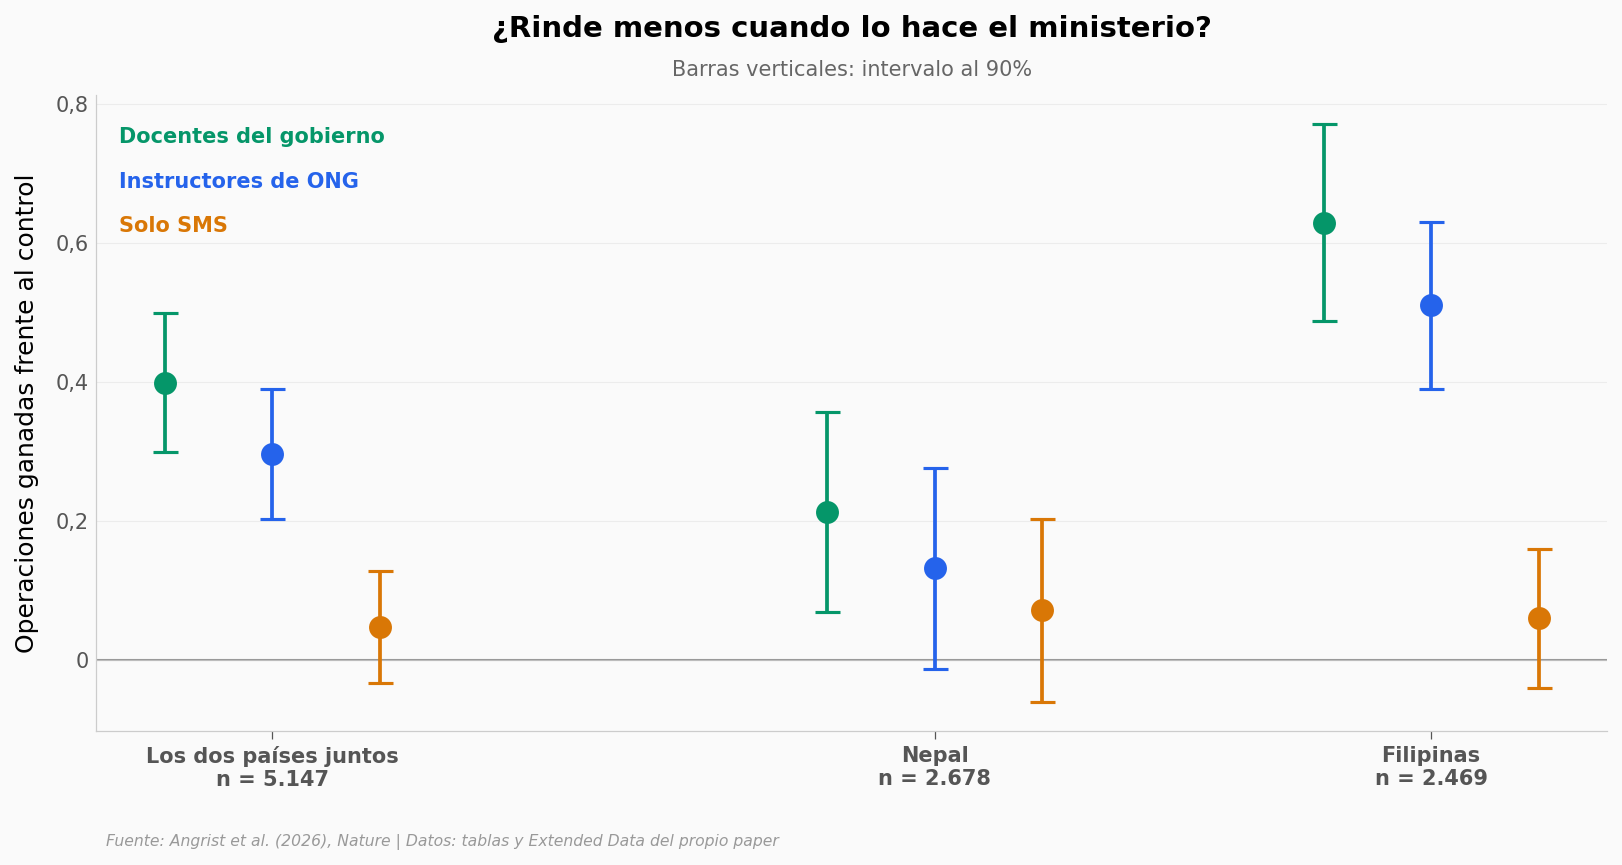

Docentes del gobierno : 0,399 operaciones (e.e. 0,061, p < 0,001)
Instructores de ONG   : 0,296 operaciones (e.e. 0,057, p < 0,001)
Diferencia            : +0,103 a favor del gobierno, p = 0,110

Con p = 0,110 no podemos distinguir las dos entregas. Ojo con la lectura:
eso NO demuestra que sean iguales — significa que este ensayo no tiene
resolución para separarlas. No encontrar una diferencia no es encontrar
una igualdad.


In [4]:
muestras = ['Todos los brazos de gobierno', 'Nepal', 'Filipinas']
brazos = [('Llamada + SMS: gobierno', 'Docentes del gobierno', COLOR_GOBIERNO),
          ('Llamada + SMS: ONG', 'Instructores de ONG', COLOR_LLAMADA),
          ('Solo SMS', 'Solo SMS', COLOR_SMS)]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axhline(0, color='#999999', linewidth=1, zorder=1)
posiciones = [0, 1.6, 2.8]

for i, muestra in enumerate(muestras):
    for j, (clave, _, color) in enumerate(brazos):
        fila = gob_ong[(gob_ong['muestra'] == muestra) & (gob_ong['brazo'] == clave)].iloc[0]
        x = posiciones[i] + (j - 1) * 0.26
        ax.errorbar(x, fila['efecto_ops'], yerr=z * fila['se'], fmt='o',
                    color=color, markersize=10, capsize=6, capthick=1.5,
                    elinewidth=1.8, zorder=5)

ax.set_xticks(posiciones)
ax.set_xticklabels(['Los dos países juntos\nn = 5.147', 'Nepal\nn = 2.678',
                    'Filipinas\nn = 2.469'], fontsize=10, fontweight='bold')
ax.set_ylabel('Operaciones ganadas frente al control')
ax.yaxis.set_major_formatter(TICKS_ES)
ax.set_title('¿Rinde menos cuando lo hace el ministerio?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Barras verticales: intervalo al 90%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

for j, (_, etiqueta, color) in enumerate(brazos):
    ax.text(0.015, 0.95 - j * 0.07, etiqueta, transform=ax.transAxes,
            fontsize=10, color=color, fontweight='bold', va='top')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/gobierno_vs_ong.png', dpi=200, bbox_inches='tight')
plt.show()

juntos = gob_ong[gob_ong['muestra'] == 'Todos los brazos de gobierno']
g = juntos[juntos['brazo'] == 'Llamada + SMS: gobierno'].iloc[0]
o = juntos[juntos['brazo'] == 'Llamada + SMS: ONG'].iloc[0]
print(f"Docentes del gobierno : {num(g['efecto_ops'])} operaciones (e.e. {num(g['se'])}, {pval(g['p_valor'])})")
print(f"Instructores de ONG   : {num(o['efecto_ops'])} operaciones (e.e. {num(o['se'])}, {pval(o['p_valor'])})")
print(f"Diferencia            : +{num(g['efecto_ops'] - o['efecto_ops'])} a favor del gobierno, "
      f"{pval(g['p_ong_vs_gobierno'])}")
print()
print('Con p = 0,110 no podemos distinguir las dos entregas. Ojo con la lectura:')
print('eso NO demuestra que sean iguales — significa que este ensayo no tiene')
print('resolución para separarlas. No encontrar una diferencia no es encontrar')
print('una igualdad.')

## ¿Y cuánto cuesta todo esto?

Aquí es donde el paper pone su titular: **casi cuatro años de instrucción de alta calidad por cada 100 dólares**. La unidad se llama LAYS — años de escolaridad ajustados por aprendizaje — y sirve para comparar intervenciones muy distintas con la misma vara.

La cifra exacta del cuerpo del paper es 3,6, no 4. Y hay un segundo número en esa tabla que descoloca.

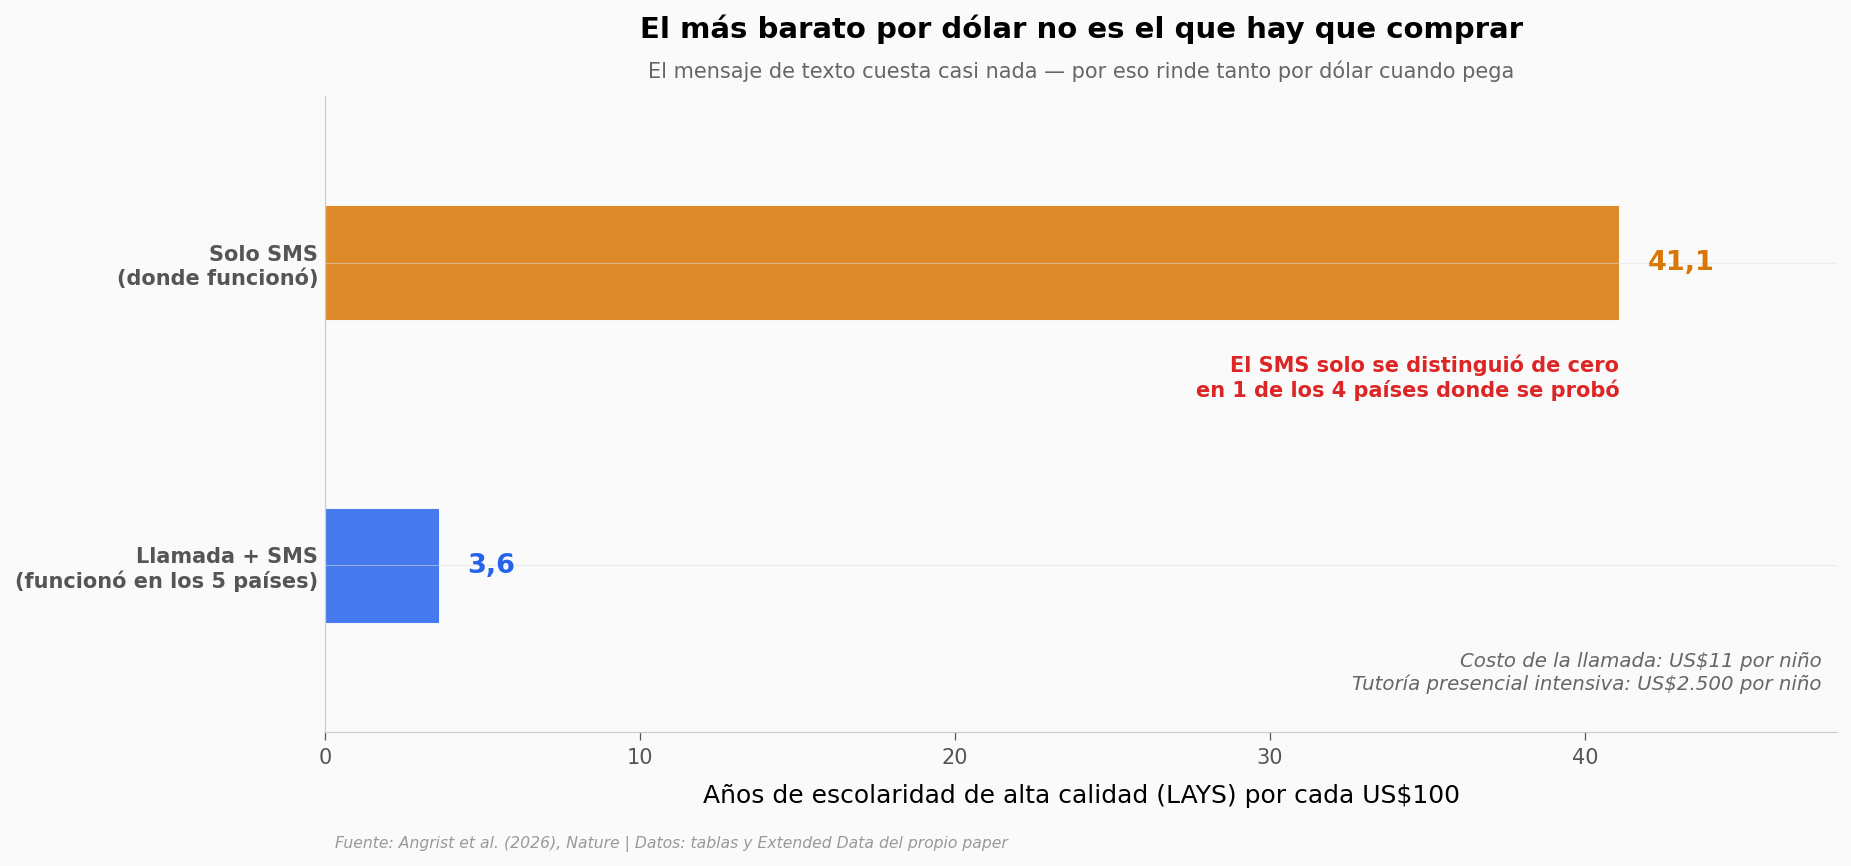

Con US$100 se cubren 9,1 niños con tutoría por llamada.
La tutoría presencial intensiva que cita el paper cuesta 227 veces más por niño (US$2.500 frente a US$11),
para un efecto de 0,19 a 0,31 desviaciones estándar. La llamada rinde 0,321:
queda justo por encima del techo de ese rango, a 1/227 del costo.

Y quienes hicieron las llamadas también se movieron — aunque dos de los
cuatro desenlaces no se distinguen de cero al 5%:
  Volvería a ser docente                     +0,158 (p < 0,001) sobre una base de 0,735
  Ayudó al aprendizaje de sus estudiantes    +0,106 (p = 0,067) sobre una base de 0,408
  Ajustar al nivel del estudiante            +0,093 (p = 0,043) sobre una base de 0,769
  Involucrar a las familias                  +0,088 (p = 0,076) sobre una base de 0,721
  n = 290 docentes


In [5]:
# Cierre cuantitativo: comparamos costo-efectividad, no distribuciones.
# Con dos intervenciones y un comparador externo, un histograma no aporta.
comp = costos.dropna(subset=['lays_por_100_usd']).sort_values('lays_por_100_usd')
etiquetas = ['Llamada + SMS\n(funcionó en los 5 países)',
             'Solo SMS\n(donde funcionó)']
colores = [COLOR_LLAMADA, COLOR_SMS]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.barh(range(len(comp)), comp['lays_por_100_usd'],
        color=colores, alpha=0.85, height=0.38, edgecolor='white')
for i, (v, c) in enumerate(zip(comp['lays_por_100_usd'], colores)):
    ax.text(v + 0.9, i, f'{v:.1f}'.replace('.', ','), va='center',
            fontsize=13, fontweight='bold', color=c)

ax.set_yticks(range(len(comp)))
ax.set_yticklabels(etiquetas, fontsize=10, fontweight='bold')
ax.set_ylim(-0.55, 1.55)
ax.set_xlim(0, 48)
ax.set_xlabel('Años de escolaridad de alta calidad (LAYS) por cada US$100')
ax.set_title('El más barato por dólar no es el que hay que comprar',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El mensaje de texto cuesta casi nada — por eso rinde tanto por dólar cuando pega',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# El caveat va en el hueco entre las dos barras: arriba se montaba sobre el título.
ax.text(41.1, 0.62, 'El SMS solo se distinguió de cero\nen 1 de los 4 países donde se probó',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold', ha='right', va='center')
ax.text(0.99, 0.06,
        f'Costo de la llamada: US${COSTO_POR_NINO_USD} por niño\n'
        f'Tutoría presencial intensiva: US${COMPARADOR_PRESENCIAL_USD:,}'.replace(',', '.')
        + ' por niño',
        transform=ax.transAxes, fontsize=9.5, color='#666666',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/costo_efectividad.png', dpi=200, bbox_inches='tight')
plt.show()

razon_costo = COMPARADOR_PRESENCIAL_USD / COSTO_POR_NINO_USD
ninos_por_100 = 100 / COSTO_POR_NINO_USD
print(f'Con US$100 se cubren {num(ninos_por_100, 1)} niños con tutoría por llamada.')
print(f'La tutoría presencial intensiva que cita el paper cuesta '
      f'{num(razon_costo, 0)} veces más por niño (US$2.500 frente a US$11),')
print('para un efecto de 0,19 a 0,31 desviaciones estándar. La llamada rinde 0,321:')
print('queda justo por encima del techo de ese rango, a 1/227 del costo.')
print()
print('Y quienes hicieron las llamadas también se movieron — aunque dos de los')
print('cuatro desenlaces no se distinguen de cero al 5%:')
for _, f in docentes.sort_values('efecto', ascending=False).iterrows():
    print(f"  {f['resultado']:<42} +{num(f['efecto'])} ({pval(f['p_valor'])}) "
          f"sobre una base de {num(f['media_control'])}")
print(f"  n = {int(docentes['n_observaciones'].iloc[0])} docentes")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La tutoría por llamada mejora el aprendizaje en los cinco países | ✅ | Los cinco efectos son positivos y distinguibles de cero (p entre 0,045 y menos de 0,001), n = 9.148 |
| El efecto agrupado es de 0,321 desviaciones estándar y no depende de cómo se junten los ensayos | ✅ | Las cuatro especificaciones caen entre 0,312 y 0,341 d.e. Ese número **es** el tamaño del efecto estandarizado: por las referencias clásicas sería pequeño-moderado, pero frente a lo que suele lograr una intervención educativa es grande, y el paper lo ubica en el top 10 de 150 revisadas |
| El mensaje de texto por sí solo reproduce el efecto de la llamada | ❌ | 0,078 d.e. contra 0,321: la llamada rinde 4,1 veces más. País por país, el SMS solo se separa de cero en operaciones ganadas únicamente en Uganda (1 de 4); en Filipinas aparece en el otro desenlace, proficiencia máxima (p = 0,019) |
| Los efectos son parecidos entre países | ❌ | Van de 0,092 (Kenia) a 1,196 (Uganda), trece veces de diferencia. I² = 98,0% (Q = 197,1; gl = 4). Cálculo nuestro sobre las cinco estimaciones del paper, que no reporta este agregado |
| Los docentes del gobierno entregan tan bien como los instructores de ONG | ⚠️ | 0,399 contra 0,296 operaciones, p = 0,110 para la diferencia. No podemos separarlas, y eso no equivale a probar que sean iguales: es una comparación de dos países, no un test de equivalencia |
| Cuesta unos 100 dólares por casi cuatro años de escolaridad de calidad | ⚠️ | El abstract redondea; el cuerpo del paper dice 3,6 LAYS por US$100. El costo es de US$11 por niño |
| Enseñar por llamada cambió cómo se sienten los docentes con su oficio | ⚠️ | «Volvería a ser docente» sube 0,158 sobre una base de 0,735 (p < 0,001), pero son 290 docentes y son respuestas de ellos mismos sobre su propio trabajo |

> **Limitaciones**
>
> - **No hay microdatos públicos.** El repositorio de replicación que anuncia el paper está vacío, así que todo lo de arriba sale de las tablas publicadas: podemos recalcular agregados y heterogeneidad, no reanalizar a los niños uno por uno. No hay forma de auditar el ajuste por controles.
> - **Cinco ensayos no son cinco réplicas.** Difieren en grados evaluados, en quién implementó y hasta en qué se aleatorizó (el hogar en India, Nepal y Uganda; el conglomerado escuela-grado en Kenia). Kenia además medía grados 1 y 2, con un techo de prueba más bajo: su efecto pequeño no es directamente comparable con el de Uganda.
> - **El resultado vale para hogares con teléfono.** El diseño no dice nada sobre los niños a los que no se puede llamar, que son justamente los más difíciles de alcanzar cuando la escuela cierra.
> - **El seguimiento perdió gente.** Al cierre se evaluó a 12.331 de los 16.936 niños inscritos (72,8%), una atrición del 27,2% muy desigual entre países: Kenia, el ensayo más grande, retuvo apenas el 52,9%. Y la muestra que entra al análisis es todavía menor, 9.148 niños — el 54% de los inscritos. El paper reporta que la atrición no difiere entre brazos.
> - **La comparación gobierno frente a ONG solo existe en dos países**, Nepal y Filipinas, y con 5.147 niños. Es la evidencia más citable del paper para política pública y también la más delgada.

## Ahora tú

1. **¿Y si el efecto de Uganda fuera un caso aparte?** Saca a Uganda del meta-análisis y vuelve a calcular el promedio ponderado y el I². ¿Sigue habiendo heterogeneidad, o Uganda la explicaba casi toda?
   *Pista:* `llamada[llamada['pais'] != 'Uganda']` y repite el bloque de `peso`, `meta` y `Q`.

2. **¿Qué cambia si mides la ganancia en porcentaje sobre el control en vez de en operaciones?** La columna `ganancia_pct` ya está calculada. ¿Sigue Uganda arriba? ¿Kenia sigue de última?
   *Pista:* `llamada[['pais', 'efecto_ops_con_controles', 'ganancia_pct']].sort_values('ganancia_pct')`

3. **¿Cuánto tendría que costar la tutoría presencial para empatar en LAYS por dólar?** Con 0,25 d.e. de efecto, despeja el costo por niño que la dejaría en 3,6 LAYS por US$100.
   *Pista:* la llamada da 0,321 d.e. por US$11; monta la regla de tres y compárala con los US$2.500 reales.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿Uganda explica sola toda la heterogeneidad?

def meta_analisis(tabla):
    """Promedio ponderado por varianza inversa + heterogeneidad (Q e I²)."""
    w = 1 / tabla['se_con_controles'] ** 2
    m = np.average(tabla['efecto_ops_con_controles'], weights=w)
    se = np.sqrt(1 / w.sum())
    q = float((w * (tabla['efecto_ops_con_controles'] - m) ** 2).sum())
    gl = len(tabla) - 1
    i2 = max(0.0, 100 * (q - gl) / q)
    return m, se, q, gl, i2

for etiqueta, tabla in (('Los cinco países', llamada),
                        ('Sin Uganda', llamada[llamada['pais'] != 'Uganda'])):
    m, se, q, gl, i2 = meta_analisis(tabla)
    print(f'{etiqueta:<18} promedio {num(m)} (e.e. {num(se)})  '
          f'I² = {num(i2, 1)}%  (Q = {num(q, 1)}, gl = {gl})')

print()
print('Sacar al país más extremo baja el promedio, pero la heterogeneidad')
print('sigue altísima: la dispersión no es cosa de un solo país.')

Los cinco países   promedio 0,374 (e.e. 0,028)  I² = 98,0%  (Q = 197,1, gl = 4)
Sin Uganda         promedio 0,224 (e.e. 0,030)  I² = 92,2%  (Q = 38,6, gl = 3)

Sacar al país más extremo baja el promedio, pero la heterogeneidad
sigue altísima: la dispersión no es cosa de un solo país.


---

## Fuentes

**Paper**: [Mobile education builds resilience during shocks in five countries](https://doi.org/10.1038/s41586-026-10990-x)  
*Nature, 2026-09-09*

**Supplementary Material**: [Extended Data Tables 1–2 — Mobile education builds resilience during shocks in five countries](https://www.nature.com/articles/s41586-026-10990-x/tables/5)  
*Nature, 2026-09-09*

**Supplementary Material**: [Supplementary Information for «Mobile education builds resilience during shocks in five countries» (MOESM1)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-10990-x/MediaObjects/41586_2026_10990_MOESM1_ESM.pdf)  
*Nature, 2026-09-09*

**Referencias citadas**: [How to improve education outcomes most efficiently? A review of the evidence using a unified metric](https://doi.org/10.1016/j.jdeveco.2024.103382)

*22 afirmaciones verificadas contra estas fuentes*

---

**Reproducibilidad.** Este notebook se ejecuta completo desde los CSV de `datos/`, transcritos de las tablas y Extended Data del paper. Cada gráfica y cada estimación sale de ese código. Unos pocos datos de contexto del texto —la penetración de internet y de celular en los hogares, la duración de cada llamada, el techo de la prueba en Kenia y la posición del efecto entre las 150 intervenciones revisadas— vienen del cuerpo del paper y no de estos CSV: no son recalculables aquí.

**Licencia.** Código bajo MIT. Los datos son del paper original (Nature, Angrist et al. 2026); su reutilización se rige por la licencia de la editorial.

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · **El Lab:** [cienciaamordiscos.com](https://cienciaamordiscos.com)